In [2]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#from catboost import CatBoostRegressor
import shap



import lightgbm as lgb

C:\Users\greyc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pré-Processamento

Lê

In [16]:
data = pd.read_parquet('alunos_enem_2018_processado.parquet')

# Poucos dados para teste
data = data.sample(frac=0.2, random_state=42)

data.shape

(289762, 40)

In [17]:
def contar_notas_abaixo(y, limiar):
    return (y < limiar).sum()

limiar = 200
qtd = contar_notas_abaixo(data['nota_media'], limiar)
print(f"Notas abaixo de {limiar}: {qtd}")


Notas abaixo de 200: 52491


In [18]:
media_geral = data['nota_media'].mean()

mae_da_media = (data['nota_media'] - media_geral).abs().mean()
print(f"Média das Notas: {media_geral:.2f}")
print(f"MAE da Média: {mae_da_media:.2f}")

Média das Notas: 423.98
MAE da Média: 165.95


In [19]:
data.columns

Index(['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
       'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA',
       'IN_TREINEIRO', 'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC',
       'TP_LINGUA', 'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006', 'Q007',
       'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016',
       'Q017', 'Q018', 'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025',
       'Q026', 'Q027', 'nota_media'],
      dtype='object')

Limpeza

In [20]:
features_candidatas = [
	'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
	'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
	'TP_ESCOLA', 'IN_TREINEIRO', 'TP_DEPENDENCIA_ADM_ESC',
	'TP_LOCALIZACAO_ESC', 'TP_LINGUA',

	'Q001', 'Q002', 'Q003', 'Q004', 'Q005', 'Q006',
	'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012',
	'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018',
	'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024',
	'Q025', 'Q026', 'Q027'
]

features = [c for c in features_candidatas if c in data.columns]

print(f"{len(features)} features utilizadas")

data = data.dropna(subset=['nota_media'])
data = data[data['nota_media'] > 200].copy()

features_ordinais = [
	'TP_FAIXA_ETARIA', 'TP_ANO_CONCLUIU',
	'Q001', 'Q002', 'Q005', 'Q006', 'Q008', 'Q009', 'Q010',
	'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017',
	'Q019', 'Q022', 'Q024', 'Q025'
]

features_nominais = [
	c for c in features
	if c not in features_ordinais
]


# Configurações
target = 'nota_media'
test_size = 0.2
random_state = 42


39 features utilizadas


In [21]:
data.shape

(237271, 40)

Dataset para arvores (com label encoding)

In [8]:
data_tree = data.copy()
encoders_tree = {}

for col in features:
	if data_tree[col].dtype == "object" or data_tree[col].dtype.name == "category":
		le = LabelEncoder()
		data_tree[col] = data_tree[col].astype(str).fillna("MISSING")
		data_tree[col] = le.fit_transform(data_tree[col])
		encoders_tree[col] = le
	else:
		data_tree[col] = data_tree[col].fillna(-1)

X_tree = data_tree[features]
y_tree = data_tree[target]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
	X_tree, y_tree, test_size=test_size, random_state=random_state
)



Data set para lineares (one hot)

In [9]:
data_linear = data.copy()
encoders_linear = {}

cols_ord = [c for c in features_ordinais if c in data.columns]
cols_nom = [c for c in features_nominais if c in data.columns]

for col in cols_ord:
	le = LabelEncoder()
	data_linear[col] = data_linear[col].astype(str).fillna("MISSING")
	data_linear[col] = le.fit_transform(data_linear[col])
	encoders_linear[col] = le

X = pd.get_dummies(
	data_linear[cols_ord + cols_nom],
	columns=cols_nom,
	drop_first=True
)

X_lin = X.fillna(X.mean())
y_lin = data_linear[target]

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
	X_lin, y_lin, test_size=test_size, random_state=random_state
)




## Treino

Modelos

In [10]:
modelos = {
    "LinearRegression": {
        "model": LinearRegression(),
        "data_encoding": "linear",
        "search": "grid",
        "params": {
            "fit_intercept": [True],
            "positive": [False]
        }
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "data_encoding": "tree",
        "search": "random",
        "params": {
            "n_estimators": randint(200, 400),
            "max_depth": [None, 10, 20, 30],
            "min_samples_leaf": randint(1, 5),
            "max_features": ["sqrt", "log2"]
        }
    },
    "LightGBM": {
        "model": lgb.LGBMRegressor(
            objective="regression",
            random_state=42,
            n_jobs=1
        ),
        "data_encoding": "tree",
        "search": "random",
        "params": {
            "n_estimators": randint(200, 500),
            "learning_rate": uniform(0.01, 0.1),
            "num_leaves": randint(20, 100),
            "max_depth": randint(-1, 20),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.6, 0.4)
        }
    },
    "CatBoostRegressor": {
        "model": CatBoostRegressor(
            loss_function='RMSE',
            random_state=42,
            verbose=0,
            allow_writing_files=False
        ),
        "data_encoding": "tree",
        "params": {
            "iterations": [500, 1000],
            "learning_rate": [0.03, 0.05, 0.1],
            "depth": [4, 6, 8],
            "l2_leaf_reg": [1, 3, 5, 7]
        }
    }

}


Busca pelos melhores parâmetros

In [11]:
resultados = {}

modelos_usados = modelos
#for nome, cfg in tqdm(modelos.items(), desc="Treinando modelos"):
for nome, cfg in modelos_usados.items():
    print(f"\nTreinando {nome}...")

    if cfg.get("search", "grid") == "random":
        search = RandomizedSearchCV(
            estimator=cfg["model"],
            param_distributions=cfg["params"],
            n_iter=10,
            scoring="neg_root_mean_squared_error",
            cv=3,
            random_state=42,
            n_jobs=2,
            verbose=0
        )
    else:
        search = GridSearchCV(
            estimator=cfg["model"],
            param_grid=cfg["params"],
            scoring="neg_root_mean_squared_error",
            cv=3,
            n_jobs=2,
            verbose=0
        )

    if modelos_usados[nome]['data_encoding'] == 'tree':
        search.fit(X_train_tree, y_train_tree)
    elif modelos_usados[nome]['data_encoding'] == 'linear':
        search.fit(X_train_lin, y_train_lin)

    resultados[nome] = {
        "model_name": nome,
        "best_score": -search.best_score_,
        "best_params": search.best_params_,
        "best_model": search.best_estimator_,
        "data_encoding": cfg["data_encoding"]
    }

print(resultados)



Treinando LinearRegression...

Treinando RandomForestRegressor...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Treinando LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037653 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 207
[LightGBM] [Info] Number of data points in the train set: 189816, number of used features: 36
[LightGBM] [Info] Start training from score 516.374340
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'LinearRegression': {'model_name': 'LinearRegression', 'best_score': np.float64(79.8413524359042), 'best_params': {'fit_intercept': True, 'positive': False}, 'best_model': LinearRegression(), 'data_encoding': 'linear'}, 'RandomForestRegressor': {'model_name': 'RandomForestRegressor', 'best_score': np.float64(78.16141004785698), 'best_params': {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 357}, 'best_model': RandomForestRegressor(max_features='log2', min_samples_leaf=4, n_estimators=357,
                      n_jobs=-1, random_state=42), 'data_encoding': 'tree'}, 'LightGBM': {'model_name': 'LightGBM', 'best_score': np.float64(77.76899006427864), 'best_params': {'colsample_bytree': np.float64(0.6923575302488596), 'learning_rate': np.float64(0.034102546602601175), 'max_depth': 5, 'n_estimators': 463, 'num_leaves': 66, 'subsample': np.float64(0.6693458614031088)}, 'best_model': LGBMRegressor(colsample_bytree=np.float64(0.6923575302488596),
            

Melhor Resultado

In [12]:
melhor_modelo_nome = None
melhor_score = float("inf")

for nome, info in resultados.items():
    if info["best_score"] < melhor_score:
        melhor_score = info["best_score"]
        melhor_modelo_nome = nome

melhor_resultado = resultados[melhor_modelo_nome]
print(melhor_resultado)

pior_modelo_nome = None
pior_score = float("-inf")

for nome, info in resultados.items():
    if info["best_score"] > pior_score:
        pior_score = info["best_score"]
        pior_modelo_nome = nome

pior_resultado = resultados[pior_modelo_nome]
print(pior_resultado)

{'model_name': 'CatBoostRegressor', 'best_score': np.float64(77.68258598740101), 'best_params': {'depth': 8, 'iterations': 1000, 'l2_leaf_reg': 7, 'learning_rate': 0.03}, 'best_model': <catboost.core.CatBoostRegressor object at 0x7926f1b795b0>, 'data_encoding': 'tree'}
{'model_name': 'LinearRegression', 'best_score': np.float64(79.8413524359042), 'best_params': {'fit_intercept': True, 'positive': False}, 'best_model': LinearRegression(), 'data_encoding': 'linear'}


## Métricas

Configurações

In [37]:
melhor_modelo = melhor_resultado['best_model']
pior_modelo = pior_resultado['best_model']


if melhor_resultado['data_encoding'] == 'tree':
    X_test_melhor, y_test_melhor = X_test_tree, y_test_tree
elif melhor_resultado['data_encoding'] == 'linear':
    X_test_melhor, y_test_melhor = X_test_lin, y_test_lin

if hasattr(melhor_modelo, "feature_names_"):
    X_test_melhor = X_test_melhor[melhor_modelo.feature_names_]


if pior_resultado['data_encoding'] == 'tree':
    X_test_pior, y_test_pior = X_test_tree, y_test_tree
elif pior_resultado['data_encoding'] == 'linear':
    X_test_pior, y_test_pior = X_test_lin, y_test_lin

if hasattr(pior_modelo, "feature_names_"):
    X_test_pior = X_test_pior[pior_modelo.feature_names_]

Estátisticas

In [38]:
y_pred = melhor_modelo.predict(X_test_melhor)

residuos = y_test_melhor - y_pred
abs_residuos = np.abs(residuos)


rmse = np.sqrt(mean_squared_error(y_test_melhor, y_pred))
mae = mean_absolute_error(y_test_melhor, y_pred)
medae = median_absolute_error(y_test_melhor, y_pred)
r2 = r2_score(y_test_melhor, y_pred)
max_error = np.max(abs_residuos)

smape = (
    100
    * np.mean(
        2 * abs_residuos
        / (np.abs(y_test_melhor) + np.abs(y_pred) + 1e-8)
    )
)


p50, p75, p90, p95 = np.percentile(abs_residuos, [50, 75, 90, 95])

erro_grave_pct = (abs_residuos > 150).mean() * 100

acc_50 = (abs_residuos <= 50).mean() * 100
acc_100 = (abs_residuos <= 100).mean() * 100


print("\n" + "=" * 60)
print(f"Avaliação do Modelo: {melhor_modelo_nome}")
print("=" * 60)

print("\nMétricas principais:")
print(f"R²        : {r2:.4f}")
print(f"RMSE      : {rmse:.2f} pontos")
print(f"MAE       : {mae:.2f} pontos (erro absoluto)")
print(f"MedAE     : {medae:.2f} pontos (erro da maioria)")
print(f"sMAPE     : {smape:.2f}% (erro médio relativo)")

print(
    f"\nInterpretação prática:"
    f"\n\tO modelo erra, em média, cerca de {mae:.1f} pontos."
    f"\n\tEm casos extremos, pode errar até {max_error:.0f} pontos."
)

print("\nDistribuição do erro absoluto:")
print(f"P50 (Mediana): {p50:.1f}")
print(f"P75          : {p75:.1f}")
print(f"P90          : {p90:.1f}")
print(f"P95          : {p95:.1f}")

print("\nQualidade do erro:")
print(f"Erro grave (>150 pts): {erro_grave_pct:.2f}%")
print(f"Acurácia ±50 pts     : {acc_50:.2f}%")
print(f"Acurácia ±100 pts    : {acc_100:.2f}%")



Avaliação do Modelo: CatBoostRegressor

Métricas principais:
R²        : 0.3806
RMSE      : 77.63 pontos
MAE       : 58.30 pontos (erro absoluto)
MedAE     : 45.46 pontos (erro da maioria)
sMAPE     : 11.79% (erro médio relativo)

Interpretação prática:
	O modelo erra, em média, cerca de 58.3 pontos.
	Em casos extremos, pode errar até 426 pontos.

Distribuição do erro absoluto:
P50 (Mediana): 45.5
P75          : 79.2
P90          : 123.1
P95          : 161.1

Qualidade do erro:
Erro grave (>150 pts): 6.03%
Acurácia ±50 pts     : 54.15%
Acurácia ±100 pts    : 83.92%


Gráficos

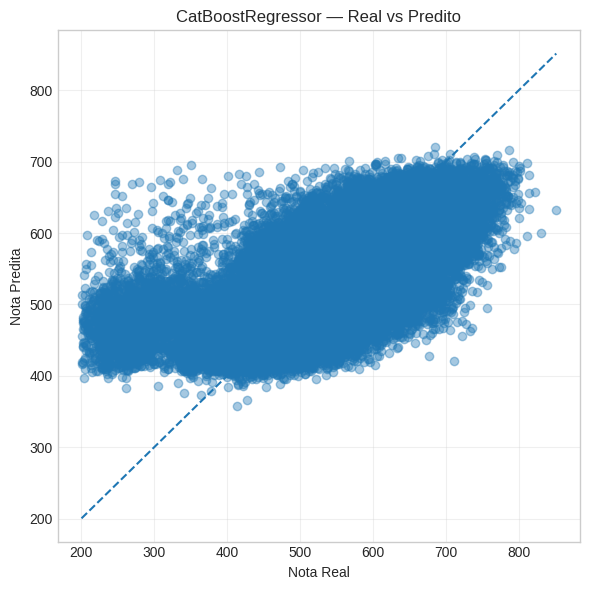

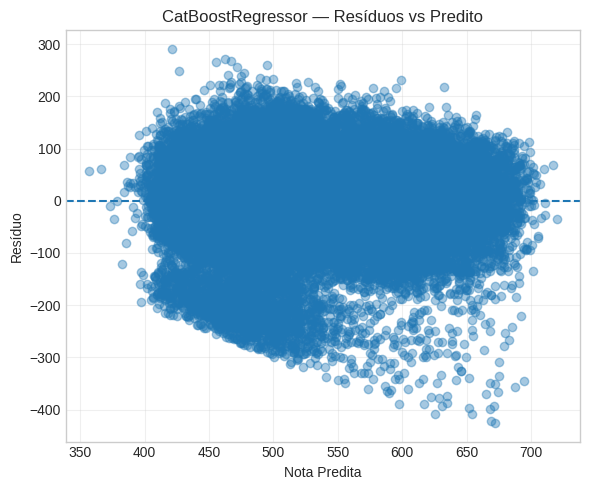

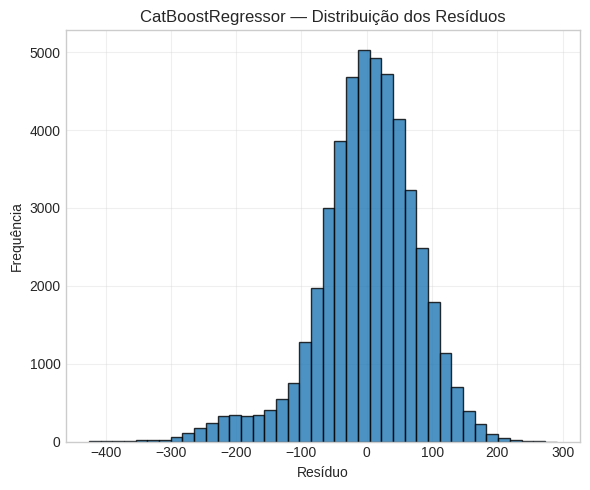

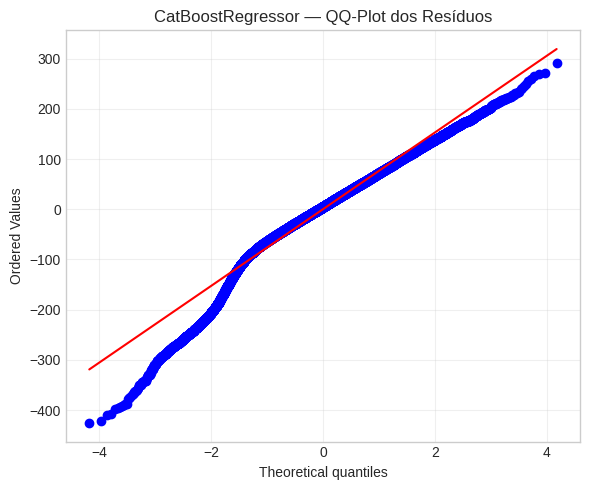

<Figure size 700x500 with 0 Axes>

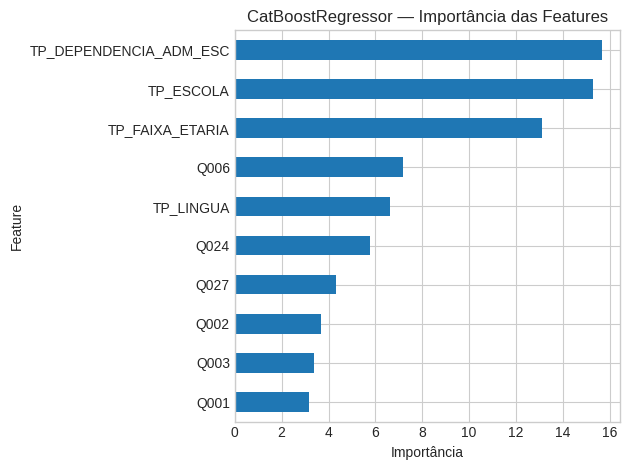

In [50]:
import matplotlib.pyplot as plt
import scipy.stats as stats


plt.figure(figsize=(6, 6))
plt.scatter(y_test_melhor, y_pred, alpha=0.4)

lims = [
    min(y_test_melhor.min(), y_pred.min()),
    max(y_test_melhor.max(), y_pred.max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Nota Real")
plt.ylabel("Nota Predita")
plt.title(f"{melhor_modelo_nome} — Real vs Predito")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuos, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Nota Predita")
plt.ylabel("Resíduo")
plt.title(f"{melhor_modelo_nome} — Resíduos vs Predito")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
plt.hist(residuos, bins=40, edgecolor="black", alpha=0.8)
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title(f"{melhor_modelo_nome} — Distribuição dos Resíduos")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 5))
stats.probplot(residuos, plot=plt)
plt.title(f"{melhor_modelo_nome} — QQ-Plot dos Resíduos")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


if hasattr(melhor_modelo, "feature_importances_"):
    importances = melhor_modelo.feature_importances_
elif hasattr(melhor_modelo, "coef_"):
    importances = np.abs(melhor_modelo.coef_).ravel()
else:
    importances = None

if importances is not None:
    feature_names = X_test_melhor.columns.tolist()

    df_importances = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importância": importances
        })
        .sort_values("Importância", ascending=False)
    )

    plt.figure(figsize=(7, 5))
    df_importances.head(10).sort_values("Importância").plot(
        kind="barh",
        x="Feature",
        y="Importância",
        legend=False
    )
    plt.title(f"{melhor_modelo_nome} — Importância das Features")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()


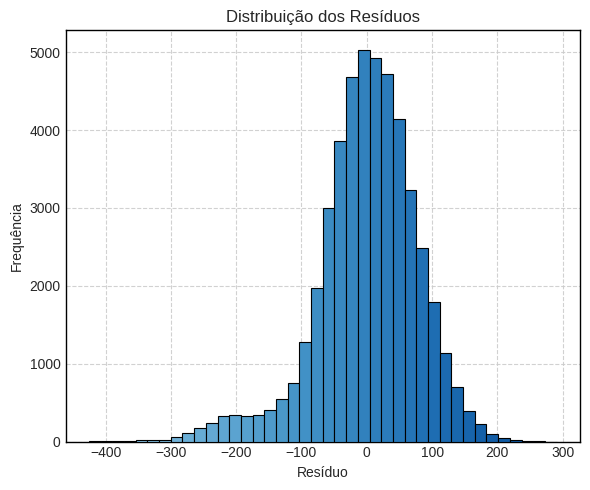

In [79]:
plt.figure(figsize=(6, 5))
ax = plt.gca()

ax.set_facecolor('white')

ax.grid(True, linestyle='--', alpha=0.9, zorder=0)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)


n, bins, patches = plt.hist(residuos, bins=40, edgecolor='black', linewidth=0.8, zorder=3)


for i, patch in enumerate(patches):
    color = plt.cm.Blues(0.4 + 0.5 * i / len(patches))
    patch.set_facecolor(color)


plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title(f"Distribuição dos Resíduos")

plt.tight_layout()
plt.show()

Gráficos Específicos

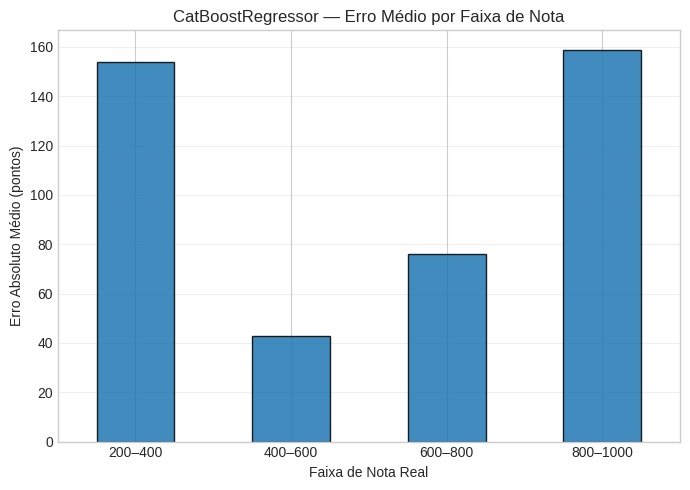

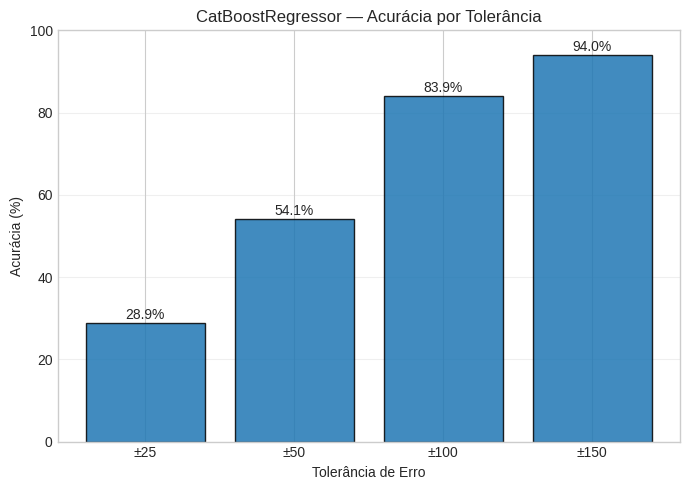

In [49]:
bins = [200, 400, 600, 800, 1000]
labels = ["200–400", "400–600", "600–800", "800–1000"]

faixas = pd.cut(
    y_test_melhor,
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_faixa = pd.DataFrame({
    "Erro_abs": np.abs(residuos),
    "Faixa": faixas
})

erro_medio = df_faixa.groupby("Faixa", observed=True)["Erro_abs"].mean()

plt.figure(figsize=(7, 5))
erro_medio.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("Erro Absoluto Médio (pontos)")
plt.xlabel("Faixa de Nota Real")
plt.title(f"{melhor_modelo_nome} — Erro Médio por Faixa de Nota")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


tolerancias = [25, 50, 100, 150]

accuracies = [
    (np.abs(residuos) <= t).mean() * 100
    for t in tolerancias
]

df_tol = pd.DataFrame({
    "Tolerância (± pontos)": [f"±{t}" for t in tolerancias],
    "Acurácia (%)": accuracies
})

plt.figure(figsize=(7, 5))
plt.bar(
    df_tol["Tolerância (± pontos)"],
    df_tol["Acurácia (%)"],
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("Acurácia (%)")
plt.xlabel("Tolerância de Erro")
plt.title(f"{melhor_modelo_nome} — Acurácia por Tolerância")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(df_tol["Acurácia (%)"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


## Métricas por grupo

In [41]:
df_erro = data.loc[X_test_melhor.index].copy()

df_erro["y_real"] = y_test_melhor.values
df_erro["y_pred"] = y_pred
df_erro["erro"] = y_test_melhor.values - y_pred
df_erro["erro_abs"] = np.abs(df_erro["erro"])

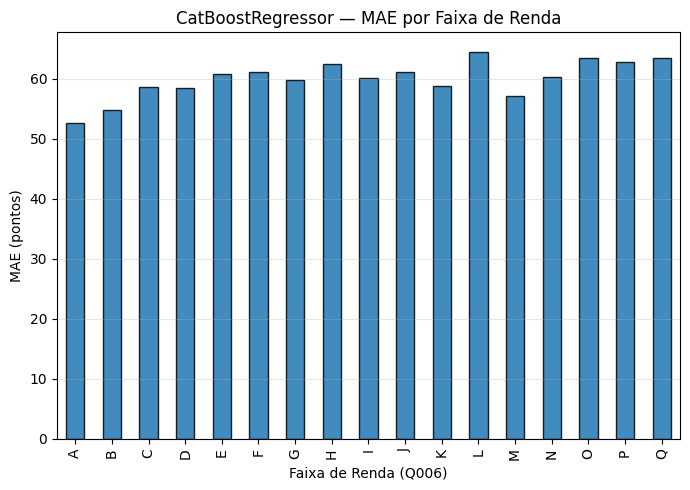

In [43]:
mae_por_renda = (
    df_erro
    .groupby("Q006")["erro_abs"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(7, 5))
mae_por_renda.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("MAE (pontos)")
plt.xlabel("Faixa de Renda (Q006)")
plt.title(f"{melhor_modelo_nome} — MAE por Faixa de Renda")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


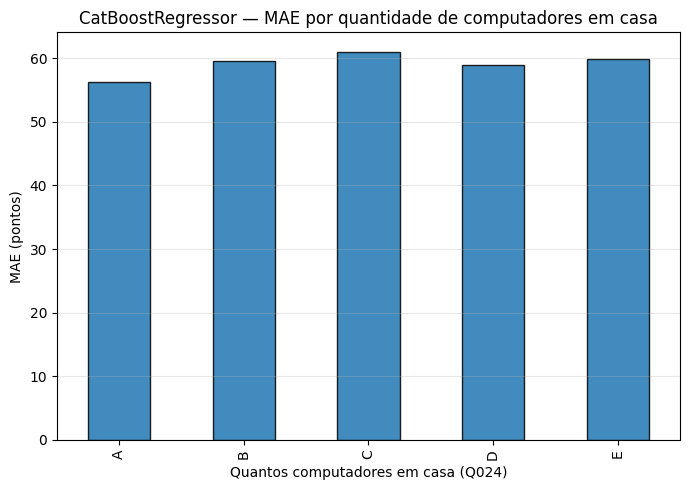

In [29]:
mae_comp = (
    df_erro
    .groupby("Q024")["erro_abs"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(7, 5))
mae_comp.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.85
)

plt.ylabel("MAE (pontos)")
plt.xlabel("Quantos computadores em casa (Q024)")
plt.title(f"{melhor_modelo_nome} — MAE por quantidade de computadores em casa")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


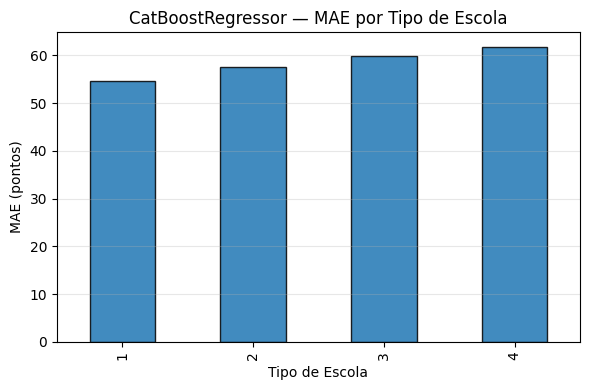

In [44]:
mae_por_escola = (
    df_erro
    .groupby("TP_DEPENDENCIA_ADM_ESC")["erro_abs"]
    .mean()
)

plt.figure(figsize=(6, 4))
mae_por_escola.plot(kind="bar", edgecolor="black", alpha=0.85)
plt.ylabel("MAE (pontos)")
plt.xlabel("Tipo de Escola")
plt.title(f"{melhor_modelo_nome} — MAE por Tipo de Escola")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Casos em que ocorrem um erro brutal

In [45]:
caso_subestimado = (
    df_erro
    .sort_values("erro", ascending=False)  # erro positivo grande
    .iloc[0]
)

caso_superestimado = (
    df_erro
    .sort_values("erro", ascending=True)  # erro negativo grande
    .iloc[0]
)

def analisar_caso(row, titulo):
    print("\n" + "=" * 60)
    print(titulo)
    print("=" * 60)

    print(f"Nota real    : {row['y_real']:.1f}")
    print(f"Nota predita : {row['y_pred']:.1f}")
    print(f"Erro         : {row['erro']:.1f} pontos")

    print("\nContexto socioeconômico:")
    print(f"- Tipo de escola           : {row['TP_DEPENDENCIA_ADM_ESC']}")
    print(f"- Localização escola       : {row['TP_LOCALIZACAO_ESC']}")
    print(f"- Faixa etária             : {row['TP_FAIXA_ETARIA']}")
    print(f"- Renda familiar (Q006)    : {row['Q006']}")
    print(f"- Escolaridade pai (Q001)  : {row['Q001']}")
    print(f"- Quantidade carros (Q010) : {row['Q010']}")

analisar_caso(
    caso_subestimado,
    "📉 CASO 1 — SUBESTIMAÇÃO EXTREMA (modelo previu muito abaixo)"
)

analisar_caso(
    caso_superestimado,
    "📈 CASO 2 — SUPERESTIMAÇÃO EXTREMA (modelo previu muito acima)"
)




📉 CASO 1 — SUBESTIMAÇÃO EXTREMA (modelo previu muito abaixo)
Nota real    : 711.8
Nota predita : 421.1
Erro         : 290.7 pontos

Contexto socioeconômico:
- Tipo de escola           : 2
- Localização escola       : 1
- Faixa etária             : 4
- Renda familiar (Q006)    : B
- Escolaridade pai (Q001)  : H
- Quantidade carros (Q010) : A

📈 CASO 2 — SUPERESTIMAÇÃO EXTREMA (modelo previu muito acima)
Nota real    : 246.9
Nota predita : 672.4
Erro         : -425.5 pontos

Contexto socioeconômico:
- Tipo de escola           : 4
- Localização escola       : 1
- Faixa etária             : 2
- Renda familiar (Q006)    : P
- Escolaridade pai (Q001)  : F
- Quantidade carros (Q010) : C


## SHAP


SHAP — Melhor modelo: CatBoostRegressor


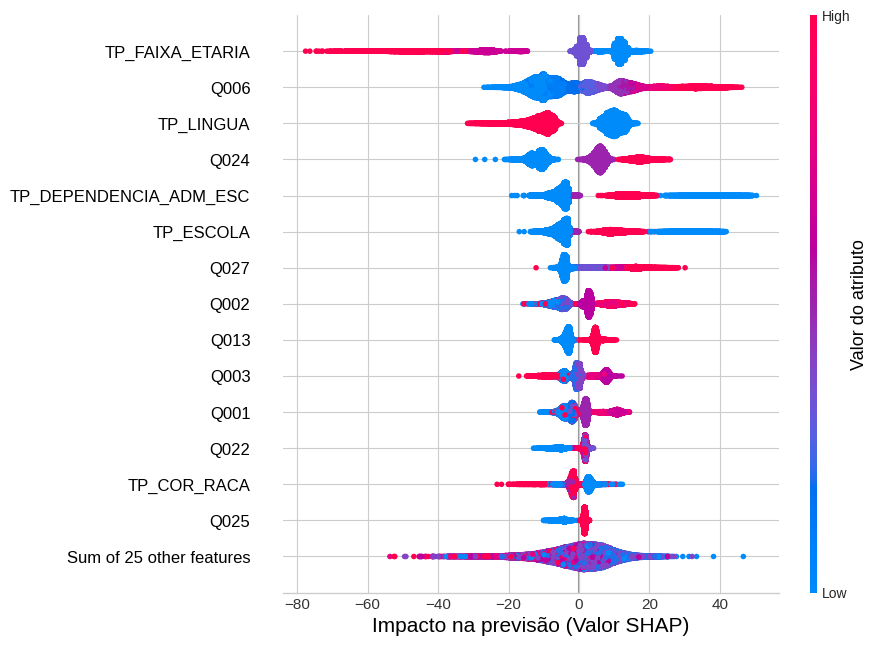


SHAP — Pior modelo


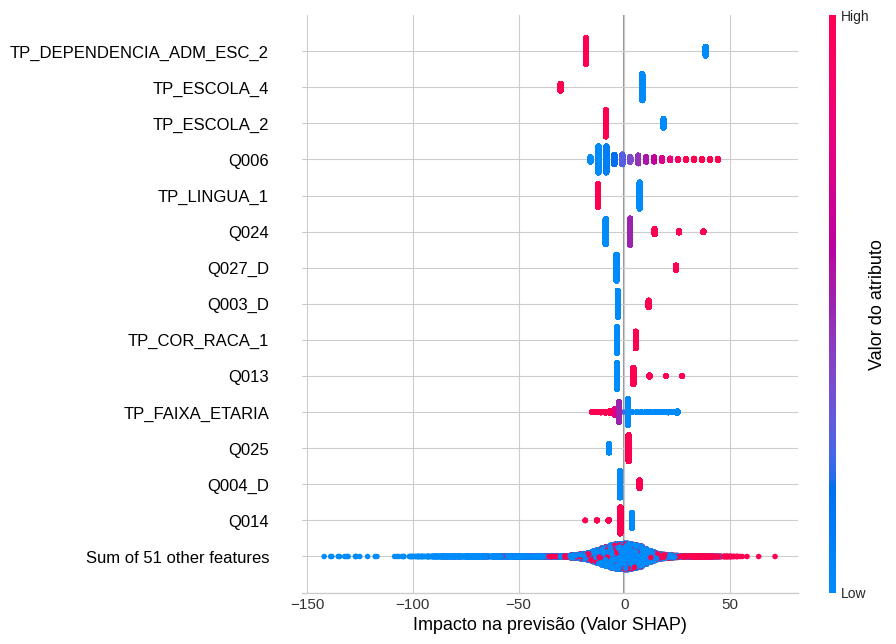

In [92]:
import shap
import matplotlib.pyplot as plt

print(f"\nSHAP — Melhor modelo: {melhor_modelo_nome}")


if melhor_resultado['data_encoding'] == 'tree':
    shap.initjs()
    explainer_melhor = shap.TreeExplainer(melhor_modelo)
    shap_values_melhor = explainer_melhor(X_test_melhor)


    shap.plots.beeswarm(
        shap_values_melhor[:100000],
        max_display=15,
        show=False
    )


    ax = plt.gca()
    ax.set_xlabel("Impacto na previsão (Valor SHAP)", fontsize=15, color="black")
    plt.yticks(fontsize=12, color="black")


    fig = plt.gcf()
    if len(fig.axes) > 1:
        cbar_ax = fig.axes[-1]
        cbar_ax.set_ylabel("Valor do atributo", fontsize=13, color="black")
        cbar_ax.tick_params(labelsize=10)

    plt.show()


elif melhor_resultado['data_encoding'] == 'linear':
    X_train_lin_numeric = X_train_lin.astype(float)
    explainer_melhor = shap.LinearExplainer(
        melhor_modelo,
        X_train_lin_numeric
    )
    shap_values_melhor = explainer_melhor(X_test_melhor.astype(float))

    shap.plots.beeswarm(
        shap_values_melhor,
        max_display=15,
        show=False
    )


    ax = plt.gca()
    ax.set_xlabel("Impacto na previsão (Valor SHAP)", fontsize=15, color="black")
    plt.yticks(fontsize=12, color="black")

    fig = plt.gcf()
    if len(fig.axes) > 1:
        cbar_ax = fig.axes[-1]
        cbar_ax.set_ylabel("Valor do atributo", fontsize=13, color="black")
        cbar_ax.tick_params(labelsize=10)

    plt.show()


print(f"\nSHAP — Pior modelo")


if pior_resultado['data_encoding'] == 'tree':
    shap.initjs()
    explainer_pior = shap.TreeExplainer(pior_modelo)
    shap_values_pior = explainer_pior(X_test_pior)

    shap.plots.beeswarm(
        shap_values_pior[:100000],
        max_display=15,
        show=False
    )

    ax = plt.gca()
    ax.set_xlabel("Impacto na previsão (Valor SHAP)", fontsize=13, color="black")
    plt.yticks(fontsize=12, color="black")

    fig = plt.gcf()
    if len(fig.axes) > 1:
        cbar_ax = fig.axes[-1]
        cbar_ax.set_ylabel("Valor do atributo", fontsize=13, color="black")
        cbar_ax.tick_params(labelsize=10)

    plt.show()


elif pior_resultado['data_encoding'] == 'linear':
    X_train_lin_numeric = X_train_lin.astype(float)
    explainer_pior = shap.LinearExplainer(
        pior_modelo,
        X_train_lin_numeric
    )
    shap_values_pior = explainer_pior(X_test_pior.astype(float))

    shap.plots.beeswarm(
        shap_values_pior,
        max_display=15,
        show=False
    )

    ax = plt.gca()
    ax.set_xlabel("Impacto na previsão (Valor SHAP)", fontsize=13, color="black")
    plt.yticks(fontsize=12, color="black")

    fig = plt.gcf()
    if len(fig.axes) > 1:
        cbar_ax = fig.axes[-1]
        cbar_ax.set_ylabel("Valor do atributo", fontsize=13, color="black")
        cbar_ax.tick_params(labelsize=10)

    plt.show()